# 005_backtest - Leader Follower Strategy
## Stage Purpose
This stage evaluates the statistical arbitrage hypotheses identified
in **004_strategy** by constructing and testing trade rules based on
leader–follower shock propagation.

Using the event response structure derived earlier, we simulate
trades that exploit delayed reactions between assets and measure
the resulting performance characteristics.

The goal of this stage is **not discovery**, but **validation**.

---

## Inputs (from 004_strategy)

Loaded from the pipeline manifest:

- `event_response_table.pkl`
  - Event-level response dataset containing:
    - leader coin
    - follower coin
    - t1–t5 response vectors
    - cumulative responses (t1sum, t3sum, t5sum)

- `leader_follower_summary.pkl`
  - Pair-level summary statistics:
    - observation counts
    - mean response metrics
    - propagation indicators

These artifacts represent the **frozen output of the strategy discovery stage**.

---

## Core Tasks

This notebook performs the following steps:

1. **Signal Construction**
   - Define trade triggers based on leader shocks
   - Evaluate follower response expectations

2. **Trade Rule Definition**
   - Entry windows (e.g. t1 or t2)
   - Exit windows (e.g. t3 or t5)
   - Optional filters (signal strength, observation counts)

3. **Trade Simulation**
   - Compute entry and exit returns
   - Aggregate event-level trades into a trade series

4. **Performance Evaluation**
   - cumulative return
   - win rate
   - Sharpe ratio
   - drawdown characteristics

---

## Outputs (Persisted in `output/005_backtest/`)

Artifacts produced by this stage:

- `trade_signals.pkl`
- `trade_results.pkl`
- `equity_curve.pkl`

These outputs are registered in the **pipeline manifest** and serve as
inputs for subsequent evaluation and reporting stages.

---

## Notes

This stage operates exclusively on artifacts generated in
**004_strategy**, ensuring that strategy discovery and validation
remain cleanly separated within the pipeline.

All experiments in this notebook should be reproducible given the
saved artifacts and manifest entries.

## Design Principle

This stage follows several design principles to ensure reproducibility and clarity:

- **Deterministic pipeline** — signals are generated only from artifacts created in earlier stages.
- **Separation of concerns** — strategy construction is separated from backtesting logic.
- **Transparent signal construction** — each step from event detection to portfolio position is explicit.
- **Artifact persistence** — outputs are saved for inspection and reuse.

This structure keeps the strategy layer modular and reproducible within the overall 


### 1. Imports and Environment Setup
### Provide the necessary imports required for to to proceed.   

In [1]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, UTC
import math
from pathlib import Path
import matplotlib.pyplot as plt

### 2. Prepare the environment for the notebook

In [3]:
startdate = "2023-01-01"
trading_days = 252
frequency = "1d"

universe = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "BNBUSDT",   # Binance Coin
    "SOLUSDT",   # Solana
    "XRPUSDT",   # Ripple
    "ADAUSDT",   # Cardano
    "DOGEUSDT",  # Dogecoin
    "AVAXUSDT",  # Avalanche
    "LTCUSDT"    # Litecoin
]

execution_delay = [0, 1, 2, 3]
execution_cost_bps = [20, 30, 40]

stage_label = "005_backtest"

OUTPUT_ROOT = Path("../output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = OUTPUT_ROOT / "manifest.pkl"

DOWNLOAD_DIR = OUTPUT_ROOT / "001_download"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

ENRICH_DIR = OUTPUT_ROOT / "002_enrich"
ENRICH_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = OUTPUT_ROOT / "003_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_DIR = OUTPUT_ROOT / "004_strategy"
STRATEGY_DIR.mkdir(parents=True, exist_ok=True)

BACKTEST_DIR = OUTPUT_ROOT / "004_strategy"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

inspection_window = 20

sigma_threshold = 3

observation_window_length = 10
observation_window = range(1, observation_window_length + 1)

holding_period = 1


### 2.1 Loading the manifest pickle file

In [4]:
if MANIFEST_FILE.exists():
    manifest = pd.read_pickle(MANIFEST_FILE)
else:
    manifest = {}

manifest.setdefault(stage_label, {})

{}

### 3. Load the pickle files from the previous stage
We use these file contents for our analysis.

In [11]:
event_response_table = pd.read_pickle(STRATEGY_DIR / "event_response_table.pkl")
event_response_vectors = pd.read_pickle(STRATEGY_DIR / "event_response_vectors.pkl")
leader_follower_summary = pd.read_pickle(STRATEGY_DIR / "leader_follower_summary.pkl")
response_matrix = pd.read_pickle(STRATEGY_DIR / "response_matrix.pkl")
sigma_class = pd.read_pickle(STRATEGY_DIR / "sigma_class.pkl")
strategy_rules = pd.read_pickle(STRATEGY_DIR / "strategy_rules.pkl")

print("event_response_table:", event_response_table.shape)
print("event_response_vectors:", event_response_vectors.shape)
print("leader_follower_summary:", leader_follower_summary.shape)
print("response_matrix:", response_matrix.shape)
print("sigma_class:", sigma_class.shape)
print("strategy_rules:", strategy_rules.shape)

display(event_response_table.head())

event_response_table: (216, 17)
event_response_vectors: (24, 6)
leader_follower_summary: (24, 6)
response_matrix: (24, 14)
sigma_class: (955, 9)
strategy_rules: (24, 13)


,event_date,r_coin,r_sigma,t_coin,t_sigma,act,t_vector,leader,leader_sigma,t1,t2,t3,t4,t5,t1sum,t3sum,t5sum
0,2023-08-17 00:00:00+00:00,ADAUSDT,-3,AVAXUSDT,-3,,"[0.025, -0.002, 0.006, -0.048, -0.019]",ADAUSDT,-3,0.025,-0.002,0.006,-0.048,-0.019,0.025,0.029,-0.038
1,2023-08-17 00:00:00+00:00,ADAUSDT,-3,AVAXUSDT,-3,,"[0.025, -0.002, 0.006, -0.048, -0.019]",ADAUSDT,-3,0.025,-0.002,0.006,-0.048,-0.019,0.025,0.029,-0.038
2,2023-08-17 00:00:00+00:00,ADAUSDT,-3,AVAXUSDT,-3,,"[0.025, -0.002, 0.006, -0.048, -0.019]",ADAUSDT,-3,0.025,-0.002,0.006,-0.048,-0.019,0.025,0.029,-0.038
3,2023-08-17 00:00:00+00:00,ADAUSDT,-3,BNBUSDT,-3,,"[-0.009, 0.002, -0.001, -0.028, 0.001]",ADAUSDT,-3,-0.009,0.002,-0.001,-0.028,0.001,-0.009,-0.008,-0.035
4,2023-08-17 00:00:00+00:00,ADAUSDT,-3,BNBUSDT,-3,,"[-0.009, 0.002, -0.001, -0.028, 0.001]",ADAUSDT,-3,-0.009,0.002,-0.001,-0.028,0.001,-0.009,-0.008,-0.035


### 4. Build the Trade log from the event dataframe

In [18]:
trades = []

for _, row in event_response_table.iterrows():

    event_date = row["event_date"]
    leader = row["r_coin"]
    follower = row["t_coin"]

    leader_sigma = row["r_sigma"]
    target_vector = row["t_vector"]

    # trade direction = same sign as leader shock
    direction = 1 if leader_sigma > 0 else -1

    # skip if vector too short
    if len(target_vector) < max(execution_delay) + holding_period:
        continue

    for delay in execution_delay:

        entry_idx = delay
        exit_idx = delay + holding_period

        entry_return = target_vector[entry_idx]
        exit_return = target_vector[exit_idx]

        gross_pnl = direction * (exit_return - entry_return)

        for cost in execution_cost_bps:

            net_pnl = gross_pnl - (cost / 10000)

            trades.append({
                "event_date": event_date,
                "leader": leader,
                "follower": follower,
                "direction": direction,
                "delay": delay,
                "cost_bps": cost,
                "entry_return": entry_return,
                "exit_return": exit_return,
                "gross_pnl": gross_pnl,
                "net_pnl": net_pnl
            })

trade_df = pd.DataFrame(trades)

print("Total trades:", len(trade_df))
display(trade_df.head(3000))

Total trades: 2592


,event_date,leader,follower,direction,delay,cost_bps,entry_return,exit_return,gross_pnl,net_pnl
0,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,20,0.025,-0.002,0.027,0.025
1,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,30,0.025,-0.002,0.027,0.024
2,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,40,0.025,-0.002,0.027,0.023
3,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,20,-0.002,0.006,-0.008,-0.010
4,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,30,-0.002,0.006,-0.008,-0.011
...,...,...,...,...,...,...,...,...,...,...
2587,2026-02-05 00:00:00+00:00,BTCUSDT,XRPUSDT,-1,2,30,0.004,0.004,-0.000,-0.003
2588,2026-02-05 00:00:00+00:00,BTCUSDT,XRPUSDT,-1,2,40,0.004,0.004,-0.000,-0.004
2589,2026-02-05 00:00:00+00:00,BTCUSDT,XRPUSDT,-1,3,20,0.004,-0.025,0.029,0.027
2590,2026-02-05 00:00:00+00:00,BTCUSDT,XRPUSDT,-1,3,30,0.004,-0.025,0.029,0.026


### 5. Confirm shape of the scenarios

In [19]:
trade_df.groupby(["delay","cost_bps"]).size()

delay  cost_bps
0      20          216
       30          216
       40          216
1      20          216
       30          216
       40          216
2      20          216
       30          216
       40          216
3      20          216
       30          216
       40          216
dtype: int64

### 6. Build Strategy Performance by delay and cost

In [20]:
summary = (
    trade_df
    .groupby(["delay","cost_bps"])["net_pnl"]
    .agg(
        trades="count",
        mean_return="mean",
        std_return="std",
        win_rate=lambda x: (x > 0).mean()
    )
)
summary["sharpe"] = (summary["mean_return"] / summary["std_return"]) * (trading_days ** 0.5)
summary

trades  mean_return  std_return  win_rate    sharpe
delay cost_bps                                                     
0     20           216    -0.005977    0.099054  0.476852 -0.957855
      30           216    -0.006977    0.099054  0.476852 -1.118116
      40           216    -0.007977    0.099054  0.462963 -1.278376
1     20           216     0.002269    0.088845  0.495370  0.405329
      30           216     0.001269    0.088845  0.481481  0.226654
      40           216     0.000269    0.088845  0.481481  0.047978
2     20           216     0.018199    0.073969  0.564815  3.905697
      30           216     0.017199    0.073969  0.564815  3.691088
      40           216     0.016199    0.073969  0.541667  3.476478
3     20           216    -0.005213    0.051253  0.504630 -1.614615
      30           216    -0.006213    0.051253  0.504630 -1.924346
      40           216    -0.007213    0.051253  0.500000 -2.234077

In [21]:
trade_df["gross_pnl"].describe()

count    2592.000000
mean        0.004319
std         0.080734
min        -0.302000
25%        -0.036000
50%         0.004000
75%         0.048000
max         0.243000
Name: gross_pnl, dtype: float64

In [22]:
trade_df.groupby("delay")["net_pnl"].mean()

delay
0   -0.006977
1    0.001269
2    0.017199
3   -0.006213
Name: net_pnl, dtype: float64

In [23]:
trade_df.groupby("delay")["net_pnl"].std()

delay
0    0.098904
1    0.088712
2    0.073859
3    0.051180
Name: net_pnl, dtype: float64

In [24]:
daily = trade_df.groupby("event_date")["net_pnl"].mean()
daily.mean() / daily.std() * np.sqrt(trading_days)

np.float64(0.5268099557457824)

In [25]:
delay2 = trade_df[trade_df["delay"] == 2]
daily = delay2.groupby("event_date")["net_pnl"].mean()

daily.mean() / daily.std() * np.sqrt(trading_days)

np.float64(5.342107943086493)

In [26]:
trade_df.groupby("follower")["net_pnl"].mean().sort_values()

follower
LTCUSDT    -0.003343
BNBUSDT    -0.001481
BTCUSDT    -0.000573
ADAUSDT     0.001969
ETHUSDT     0.002194
DOGEUSDT    0.002583
XRPUSDT     0.002889
SOLUSDT     0.003370
AVAXUSDT    0.005239
Name: net_pnl, dtype: float64

In [27]:
split_date = "2025-01-01"

train = trade_df[trade_df["event_date"] < split_date]
test  = trade_df[trade_df["event_date"] >= split_date]

def sharpe(df):
    daily = df.groupby("event_date")["net_pnl"].mean()
    return daily.mean() / daily.std() * np.sqrt(trading_days)

print("TRAIN Sharpe:", sharpe(train))
print("TEST  Sharpe:", sharpe(test))

TRAIN Sharpe: -6.845190154991632
TEST  Sharpe: 6.210253264059558


In [28]:

random_df = trade_df.copy()

coins = trade_df["leader"].unique()

random_df["leader"] = np.random.choice(coins, size=len(random_df))

daily = random_df.groupby("event_date")["net_pnl"].mean()

random_sharpe = daily.mean() / daily.std() * np.sqrt(trading_days)

print("Randomized Leader Sharpe:", random_sharpe)

Randomized Leader Sharpe: 0.5268099557457824


In [31]:
print(trade_df.columns)

Index(['event_date', 'leader', 'follower', 'direction', 'delay', 'cost_bps',
       'entry_return', 'exit_return', 'gross_pnl', 'net_pnl'],
      dtype='object')


In [32]:
corr = trade_df["entry_return"].corr(trade_df["exit_return"])
print("Entry/Exit correlation:", corr)

Entry/Exit correlation: -0.29837117928310974


In [33]:
delay2 = trade_df[trade_df["delay"] == 2]

corr = delay2["entry_return"].corr(delay2["exit_return"])

print("Delay=2 entry/exit correlation:", corr)

Delay=2 entry/exit correlation: -0.47662341620832016


In [34]:
trade_df.groupby("delay")["entry_return"].mean()

delay
0    0.002856
1    0.018667
2    0.002954
3   -0.007458
Name: entry_return, dtype: float64

In [35]:
trade_df.groupby("delay")["exit_return"].mean()

delay
0    0.018667
1    0.002954
2   -0.007458
3   -0.006208
Name: exit_return, dtype: float64

Average move by delay:
delay
0    0.015810
1   -0.015713
2   -0.010412
3    0.001250
Name: move, dtype: float64


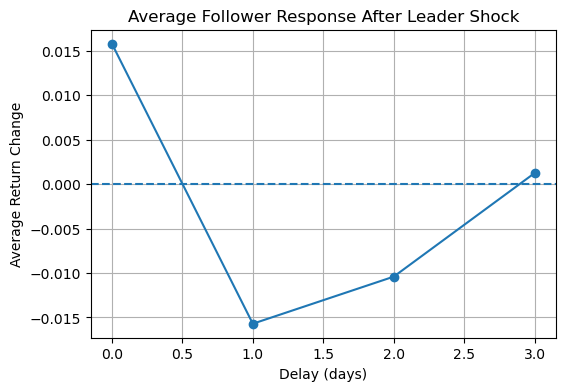

In [37]:
trade_df["move"] = trade_df["exit_return"] - trade_df["entry_return"]

delay_curve = trade_df.groupby("delay")["move"].mean()

print("Average move by delay:")
print(delay_curve)

plt.figure(figsize=(6,4))
plt.plot(delay_curve.index, delay_curve.values, marker="o")

plt.axhline(0, linestyle="--")
plt.title("Average Follower Response After Leader Shock")
plt.xlabel("Delay (days)")
plt.ylabel("Average Return Change")

plt.grid(True)
plt.show()

In [38]:
dip_trades = trade_df[trade_df["delay"] == 1].copy()

# Trade return: buy at overshoot, exit next period
dip_trades["strategy_return"] = -(dip_trades["exit_return"] - dip_trades["entry_return"])

# Apply trading cost
dip_trades["strategy_net"] = dip_trades["strategy_return"] - dip_trades["cost_bps"] / 10000

print("Number of trades:", len(dip_trades))

daily = dip_trades.groupby("event_date")["strategy_net"].mean()

print("\nDaily mean return:", daily.mean())
print("Daily std:", daily.std())

sharpe = daily.mean() / daily.std() * np.sqrt(trading_days)

print("\nDip strategy Sharpe:", sharpe)

print("\nTrade return distribution:")
print(dip_trades["strategy_net"].describe())

Number of trades: 648

Daily mean return: 0.010712053571428569
Daily std: 0.07087343364435068

Dip strategy Sharpe: 2.3993275045502496

Trade return distribution:
count    648.000000
mean       0.012713
std        0.087411
min       -0.204000
25%       -0.026000
50%        0.011000
75%        0.065000
max        0.300000
Name: strategy_net, dtype: float64


In [39]:
print(trade_df.columns)
trade_df.head()

Index(['event_date', 'leader', 'follower', 'direction', 'delay', 'cost_bps',
       'entry_return', 'exit_return', 'gross_pnl', 'net_pnl', 'move'],
      dtype='object')


,event_date,leader,follower,direction,delay,cost_bps,entry_return,exit_return,gross_pnl,net_pnl,move
0,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,20,0.025,-0.002,0.027,0.025,-0.027
1,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,30,0.025,-0.002,0.027,0.024,-0.027
2,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,40,0.025,-0.002,0.027,0.023,-0.027
3,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,20,-0.002,0.006,-0.008,-0.010,0.008
4,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,30,-0.002,0.006,-0.008,-0.011,0.008


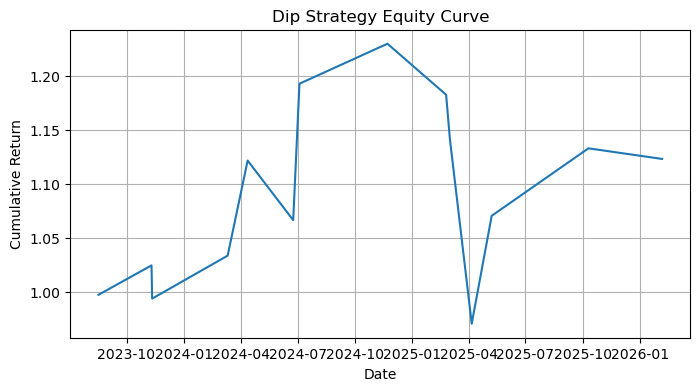

In [40]:
equity_curve = (1 + daily).cumprod()

plt.figure(figsize=(8,4))
plt.plot(equity_curve.index, equity_curve.values)
plt.title("Dip Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

In [41]:
delay_curve = trade_df.groupby("delay")["move"].mean()
print(delay_curve)

delay
0    0.015810
1   -0.015713
2   -0.010412
3    0.001250
Name: move, dtype: float64


In [44]:
pair_response = (
    dip_trades
    .groupby(["leader", "follower"])["strategy_net"]
    .agg(["mean", "count"])
    .reset_index()
)

# Only keep pairs with enough observations
pair_response = pair_response[pair_response["count"] >= 10]

pair_response.head(40)

,leader,follower,mean,count
0,ADAUSDT,AVAXUSDT,0.008211,57
1,ADAUSDT,BNBUSDT,0.039842,57
2,ADAUSDT,BTCUSDT,0.000632,57
3,ADAUSDT,DOGEUSDT,0.021316,57
4,ADAUSDT,ETHUSDT,0.004947,57
5,ADAUSDT,LTCUSDT,-0.000211,57
6,ADAUSDT,SOLUSDT,0.042789,57
7,ADAUSDT,XRPUSDT,-0.005105,57
8,AVAXUSDT,ADAUSDT,0.035600,15
9,AVAXUSDT,BNBUSDT,0.049000,15


In [47]:
summary_rows = []

for cost, df in trade_df.groupby("cost_bps"):

    daily_returns = df.groupby("event_date")["net_pnl"].mean().sort_index()
    equity_curve = (1 + daily_returns).cumprod()

    total_return = equity_curve.iloc[-1] - 1
    volatility = daily_returns.std() * np.sqrt(trading_days)

    sharpe = (
        daily_returns.mean() /
        daily_returns.std()
    ) * np.sqrt(trading_days)

    drawdown = equity_curve / equity_curve.cummax() - 1
    max_drawdown = drawdown.min()

    summary_rows.append({
        "cost_bps": cost,
        "total_return": total_return,
        "volatility": volatility,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "trade_count": len(df)
    })

stress_summary = pd.DataFrame(summary_rows).sort_values("cost_bps")

stress_summary

,cost_bps,total_return,volatility,sharpe,max_drawdown,trade_count
0,20,0.019815,0.244781,1.556301,-0.046157,864
1,30,0.005648,0.244781,0.526810,-0.050962,864
2,40,-0.008336,0.244781,-0.502681,-0.055748,864


### 999. Calculate the remaining and persist to output

In [48]:
BACKTEST_DIR = OUTPUT_ROOT / "005_backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

daily_returns = trade_df.groupby("event_date")["net_pnl"].mean()
daily_returns = daily_returns.sort_index()

equity_curve = (1 + daily_returns).cumprod()

total_return = equity_curve.iloc[-1] - 1
volatility = daily_returns.std() * np.sqrt(trading_days)

sharpe = (
    daily_returns.mean() /
    daily_returns.std()
) * np.sqrt(trading_days)

drawdown = equity_curve / equity_curve.cummax() - 1
max_drawdown = drawdown.min()

performance_summary = pd.Series({
    "total_return": total_return,
    "volatility": volatility,
    "sharpe": sharpe,
    "max_drawdown": max_drawdown,
    "avg_trade": trade_df["net_pnl"].mean(),
    "trade_count": len(trade_df)
})

trade_df.to_pickle(BACKTEST_DIR / "trades.pkl")
daily_returns.to_pickle(BACKTEST_DIR / "daily_returns.pkl")
equity_curve.to_pickle(BACKTEST_DIR / "equity_curve.pkl")
performance_summary.to_pickle(BACKTEST_DIR / "performance_summary.pkl")

stress_summary.to_pickle(BACKTEST_DIR / "stress_summary.pkl")
stress_summary.to_csv(BACKTEST_DIR / "stress_summary.csv", index=False)

print("Saved artifacts to:", BACKTEST_DIR)
print()

print("Combined performance:")
print(performance_summary)
print()

print("Cost stress results:")
print(stress_summary)

Saved artifacts to: ../output/005_backtest

Combined performance:
total_return       0.005648
volatility         0.244781
sharpe             0.526810
max_drawdown      -0.050962
avg_trade          0.001319
trade_count     2592.000000
dtype: float64

Cost stress results:
   cost_bps  total_return  volatility    sharpe  max_drawdown  trade_count
0        20      0.019815    0.244781  1.556301     -0.046157          864
1        30      0.005648    0.244781  0.526810     -0.050962          864
2        40     -0.008336    0.244781 -0.502681     -0.055748          864
